# Olivia Weihmuller
<h1 align="center">TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.</h1>

En esta tarea semanal se buscó analizar cómo afectan distintos grados de desintodia frecuencial a una senal senoidal con potencia normalizada (varianza unitaria). La desintonía se evalúa modificando la frecuencia del tono $f_0$ respecto a la grilla discreta de análisis de la DFT, definida por la relación $f_0 = k_0 \cdot \frac{f_s}{N} = k_0 \cdot \Delta f$, donde $\Delta f$ es el espaciado entre canales o bins. 
Al tomar un bloque de $N$ muestras de la senoidal, el proceso es matemáticamente equivalente a multiplicar la señal por una ventana rectangular. En el dominio de la frecuencia, por la propiedad de convolucion, el espectro resultamte corresponde a la convolucion senoidal con la transfromada de la ventana, dando lugar a una funcion de tipo sinc periodica. Esta función posee un lóbulo principal central, lóbulos lateras y ceros exactos espaciados entre si a una distancia constante de $\Delta f = \frac{f_s}{N}$. Cuando la frecuencia de la senoidal coincide exactamente con un múltiplo entero del paso frecuencial ($f_0 = k_0 \cdot \Delta f$), es decir, entran ciclos completos en la ventana), el pico del lóbulo principal coincide exactamente con el bin $k_0$ de la DFT. Debido a que el espaciado entre ceros de la funcion sinc es igual al espaciado entre bins, todos los demás bins de la DFT evalúan la curva exactamente en sus cruces por cero. En consecuencia, no se observa desparramo y la energía aparece concentrada únicamente en un pulso espectral. Por el contrario, si la senoidal sufre una desintonia ($f_0 = (k_0 + \delta)\Delta f$ con $\delta \neq 0$), el pico del lobulo principal se desplaza y ya no coincide con nigun bin discreto. Esto provoca dos efectos principales: 
**Pérdida por acanalado:** Es la atenuación en la amplitud del pico que registra la DFT cuando la frecuencia de la señal cae en un punto intermedio entre dos bins. Al no coincidir con la grilla discreta de análisis, la DFT no muestrea la cúspide del lóbulo principal de la sinc, sino una de sus laderas, haciendo que la señal parezca tener menos amplitud y potencia de la que realmente posee. 
**Y desparramo espectral:** La energia de la senoidal se "desparrama" hacia todos los demas bins vecinas, ya que la grilla de la DFT pasa a muestrear las "lomas" de los lobulos lateras en lugar de los ceros. La distorsión visual y el desaprramo son máximos cuando la frecuencia cae justo en el punto medio entre dos bins ($\delta = 0{,}5$). A pesar de las diferencias en la apariencia de los gráficos espectrales, la energía total de la senal en el tiempo se mantiene constante en todos los casos. Según el Teorema de Parseval, la suma de energía en el tiempo equivale a la suma de la Densidad Espectral de Potencia en la frecuencia. La diferencia visual radica en que la senal desintonizada pone al descubierto los lóbulos secundarios de la sinc, los cuales permanencen "ocultos" en la senoidal sintonizada debudo a la coincidencia con los ceros de evaluación de la DFT. 
Finalmente, se evalua **la tecnica de relleno de ceros (Zero Padding)**, que consiste en extender la secuencia temporal agregando muestras nulas al final (pasando de $N$ a $M = 10 \cdot N$ muestras). Al graficar la Densidad Espectral de Potencia, el zero padding actua como una interpolacion en el dominio de la frecuencia, permitiendo visualizar la curva continia de la DTFT de manera suave y definida (revelando el lobulo prinicpal y los lateras). Cabe destecar que esto mejora la definicon visual del gráfico, pero no altera la resolucion esectral fisica del sistema.

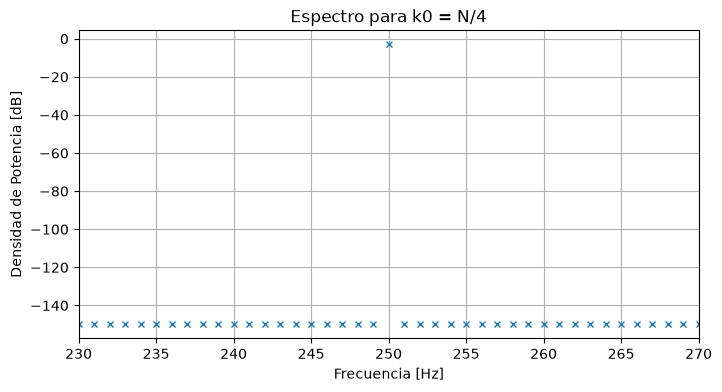

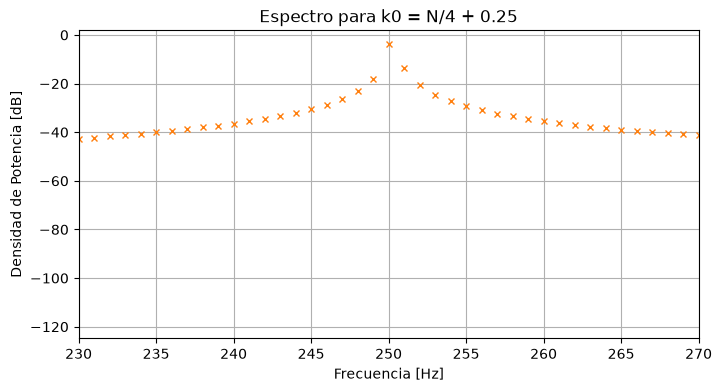

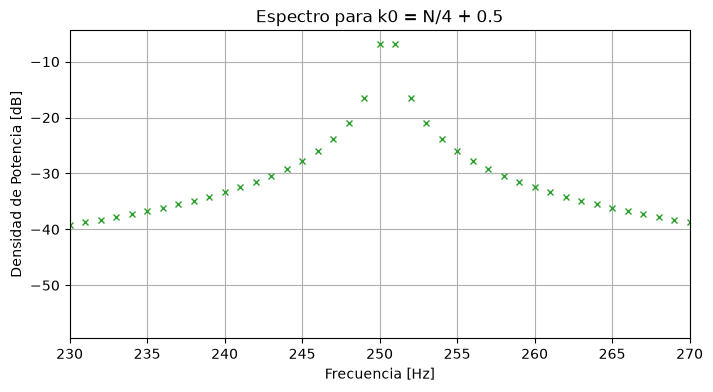

In [34]:
import matplotlib.pyplot as plt
import numpy as np

N = 1000
fs = 1000
ph = 0
ff = 1
Ps = 1         # W, energía normalizada (de la consigna) (POTENCIA DE LA SENAL)
amp = np.sqrt(2 * Ps) 

M = N*10

# POTENCIA UNITARIA, parametrizada por k0 ; f0=k0*deltak

# DESPARRAMO ESPECTRAL

# cad bin k vive en f_k= k*delta k
# la idea de este ejericio es ver que f0 no caiga dentro de un multiplo de delta f
# en este tp la idea es que caiga fuera para ver que pasa

# calcaula la DFT de tus N muestras, matemáticamente estás asumiendo que esas N muestras son un período completo de una señal que se repite infinitamente

#si 𝑓0 es un múltiplo entero de Δ𝑓, la senoidal completa un número entero de ciclos exactos dentro de la ventana de 
# N muestras. Entonces, al "copiar y pegar" esa ventana infinitas veces (lo que la DFT asume), el empalme entre una copia 
#y la siguiente es perfectamente suave — no hay ningún salto ni discontinuidad en la unión. El resultado es la senoidal periódica ideal, 
#y su espectro da un pico perfectamente angosto en un solo bin.
# lo que se hace es estas multiplciandoe las N muestras que seleccionaste por una ventana (w(n))
# x_obs[n] = w[n]*x[n]
# como multiplicar en un dominio signifca convolucionar en el otro, lo que se hac es convolucionar la delta (del seno)
# con la convolucionn de la cajita que es sinc.

def mi_funcion_sen(amp, dc, k0, ph, N, fs):
    
    df= fs/N
    
    f0= k0*df

    
    nn = np.arange(N)
    xx = amp * np.sin(2 * np.pi * f0 * nn/fs + ph)
    tt = nn/fs
    return(tt, xx)

def espectro_db(x, nfft, eps=1e-15):
    N_real = len(x)                          # el N real, siempre disponible
    fft_x = np.fft.fft(x, n=nfft)
    pot_por_bin = (np.abs(fft_x)**2) / (N_real**2)   # normalizás con el real
    return 10*np.log10(pot_por_bin[:nfft//2] + eps)

tt, x1= mi_funcion_sen(amp=amp, dc=0, k0=N/4, ph=0, N=N, fs=fs)

tt, x2= mi_funcion_sen(amp=amp, dc=0, k0=(N/4)+0.25, ph=0, N=N, fs=fs)

tt, x3= mi_funcion_sen(amp=amp, dc=0, k0=(N/4)+0.5, ph=0, N=N, fs=fs)

# densidad espectral en potencia, es la potencia que le corresponde a cada bin de frecuencia
# en eje y potenica en dB y frecuencia en el eje x

#%% calculo fft de la senales

x1_fft_db = espectro_db(x1, nfft=N)
x2_fft_db = espectro_db(x2, nfft=N)
x3_fft_db = espectro_db(x3, nfft=N)


freqs = np.fft.fftfreq(N, d=1/fs)

# si noe sentero e dearrama en los bins q tenes
# Creamos una grilla de 2 filas x 2 columnas
# 1. k0 = N/4
plt.figure(figsize=(8, 4))
plt.plot(freqs[:N//2], x1_fft_db, 'x', label='k0=N/4', markersize=4)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title('Espectro para k0 = N/4')
plt.xlim(230, 270)
plt.grid(True)
plt.show()

# 2. k0 = N/4 + 0.25
plt.figure(figsize=(8, 4))
plt.plot(freqs[:N//2], x2_fft_db, 'x', label='k0=N/4+0.25', color='tab:orange', markersize=4)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title('Espectro para k0 = N/4 + 0.25')
plt.xlim(230, 270)
plt.grid(True)
plt.show()

# 3. k0 = N/4 + 0.5
plt.figure(figsize=(8, 4))
plt.plot(freqs[:N//2], x3_fft_db, 'x', label='k0=N/4+0.5', color='tab:green', markersize=4)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title('Espectro para k0 = N/4 + 0.5')
plt.grid(True)
plt.xlim(230, 270)
plt.show()

Como se predijo teoricamente, en espctro $k_0 = N/4$ (caso sintonizado, $\delta = 0$) (figura de Espectro para k0=N/4), se observa un único pulso espectral limpio. Dado que la frecnuencia de la senoidal coincide exactamete con un bin de la DFT, las demás muestras coinciden con los ceeros periodicos de la funcion sinc. Los valores cercanos a -140 dB no representan desparramo real, sino que en la práctica equivalen a cero debido a la precisión numérica de la computadora. Por el contrario, en los casos con desintonia ($k_0 = N/4 + 0,25$ y $k_0 = N/4 + 0,5$), se evidencia claramente el fenomeno de desparramo espectral. Al no coincidir la frecuencia de la senal con la grilla discreta de la DFT, las muestras caen sobre las laderas y lóbulos laterales del sinc, distribuyendo la energía entre múltiples bins adyacentes. Asimismo, se observa la pérdida por acanalado (scalloping loss), donde la amplitud medida en el bin principal disminuye —siendo máxima esta atenuación para $\delta = 0,5$— debido a que la DFT no evalúa el máximo del lóbulo central. A pesar de estas diferencias visuales, por el Teorema de Parseval, la energía total integrada en el dominio frecuencial se conserva constante en los tres casos

In [35]:
#%% b) la energia de las tres es la misma
# Verificación de potencia unitaria (Parseval)

# Potencia medida en el TIEMPO (directo sobre las muestras)
pot_tiempo_1 = np.mean(x1**2)
pot_tiempo_2 = np.mean(x2**2)
pot_tiempo_3 = np.mean(x3**2)

# Potencia medida en FRECUENCIA (suma de TODOS los bins, sin recortar a N//2)
pot_frec_1 = np.sum(np.abs(np.fft.fft(x1))**2) / N**2
pot_frec_2 = np.sum(np.abs(np.fft.fft(x2))**2) / N**2
pot_frec_3 = np.sum(np.abs(np.fft.fft(x3))**2) / N**2

print("--- Verificación Parseval: potencia unitaria ---")
print(f"k0=N/4      -> Tiempo: {pot_tiempo_1:.6f} W | Frecuencia: {pot_frec_1:.6f} W")
print(f"k0=N/4+0.25 -> Tiempo: {pot_tiempo_2:.6f} W | Frecuencia: {pot_frec_2:.6f} W")
print(f"k0=N/4+0.5  -> Tiempo: {pot_tiempo_3:.6f} W | Frecuencia: {pot_frec_3:.6f} W")

# la porencia total de cada uno es igual
# es decir todos tienen la misma energia pro esta distribuida de manera distinta


--- Verificación Parseval: potencia unitaria ---
k0=N/4      -> Tiempo: 1.000000 W | Frecuencia: 1.000000 W
k0=N/4+0.25 -> Tiempo: 0.999000 W | Frecuencia: 0.999000 W
k0=N/4+0.5  -> Tiempo: 1.000000 W | Frecuencia: 1.000000 W


Al calcular y comparar la energía de las senales tanto en el dominio del tiempo como en el de la frecuencia medinate la aplicación del Teorema de Parseval ($\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$)1, se verificó cuantitativamente la conservación de la energía unitaria ($E = 1$) en los tres casos. Este resultado confirma que se trata fundamentalmente de la misma señal con la misma energia. La diferencia visual observada en las Densidades Espectrales de Potencia (PSD) no responde a una alteración en la energía de la señal, sino al muestreo frecuencial de la DFT: mientras que en el caso sintonizado la grilla evalúa justo en los ceros de la sinc (ocultando sus lóbulos), en los casos desintonizados la grilla muestrea las laderas y lóbulos secundarios, redistribuyendo la energía entre múltiples bins (spectral leakage).

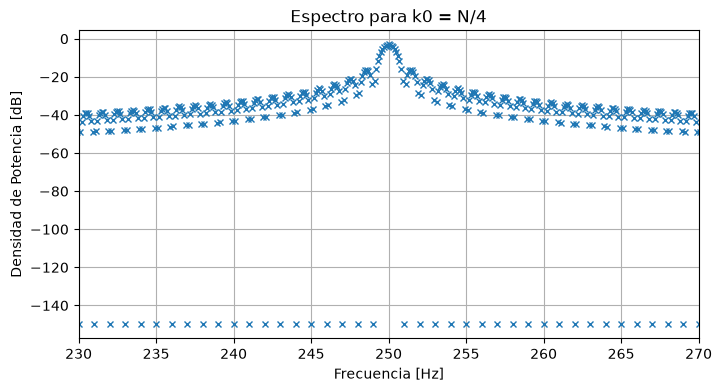

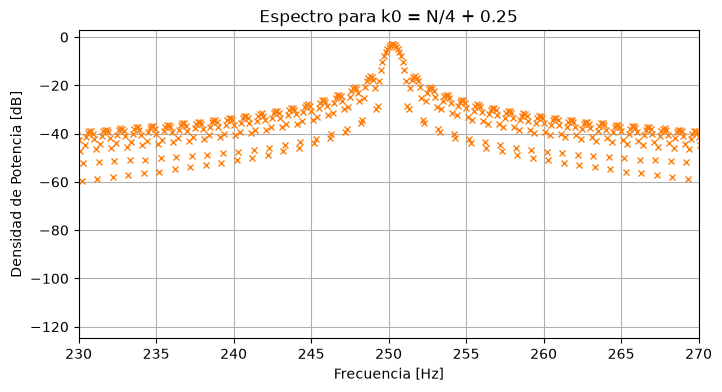

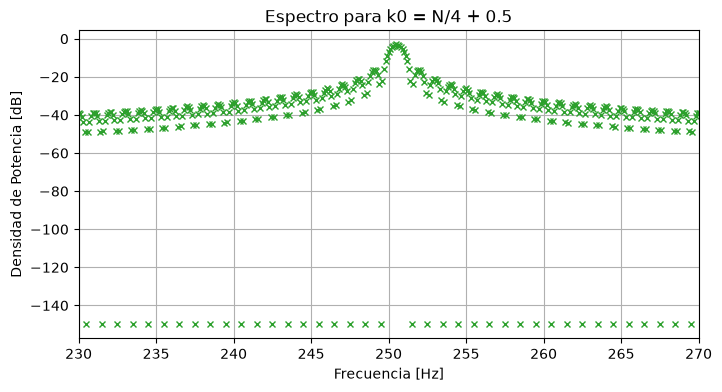

In [36]:
#%% c)

x1_zp_fft_db = espectro_db(x1, nfft=M)
x2_zp_fft_db = espectro_db(x2, nfft=M)
x3_zp_fft_db = espectro_db(x3, nfft=M)

# la imagen se ve más grande y suave, pero no aparece ningún detalle nuevo que no estuviera ya en los píxeles originales.
# sirve para interpolar el espectro en mas puntos

freqs_c = np.fft.fftfreq(M, d=1/fs)

# 1. k0 = N/4
plt.figure(figsize=(8, 4))
plt.plot(freqs_c[:M//2], x1_zp_fft_db, 'x', label='k0=N/4', markersize=4)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title('Espectro para k0 = N/4')
plt.xlim(230, 270)
plt.grid(True)
plt.show()

# 2. k0 = N/4 + 0.25
plt.figure(figsize=(8, 4))
plt.plot(freqs_c[:M//2], x2_zp_fft_db, 'x', label='k0=N/4+0.25', color='tab:orange', markersize=4)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title('Espectro para k0 = N/4 + 0.25')
plt.xlim(230, 270)
plt.grid(True)
plt.show()

# 3. k0 = N/4 + 0.5
plt.figure(figsize=(8, 4))
plt.plot(freqs_c[:M//2], x3_zp_fft_db, 'x', label='k0=N/4+0.5', color='tab:green', markersize=4)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title('Espectro para k0 = N/4 + 0.5')
plt.grid(True)
plt.xlim(230, 270)
plt.show()

Una vez aplicado el zero padding (extandiendo la secuencia temporal a $M = 10N$ muestras), se observa una grilla de evaluación frecuencial $10$ veces más densa. Esto genera una interpolación en el dominio de la frecuencia que dibuja de forma suave y continua la envolvente de la DTFT subyacente. En los tres gráficos ($k_0 = N/4$, $k_0 = N/4 + 0{,}25$ y $k_0 = N/4 + 0{,}5$) se aprecia con claridad la forma completa de la función sinc periódica, producto de la convolución espectral provocada por el ventaneo rectangular. Incluso para la senoidal sintonizada ($k_0 = N/4$), el zero padding saca a la luz los lóbulos secundarios que en el gráfico sin padding permanecían ocultos debido a que la grilla original evaluaba justo en los ceros de la función. Asimismo, al muestrear más cerca de la cima del lóbulo central, se recupera el valor real del pico de amplitud, atenuando la pérdida por acanalado. Es importante mencionar que esta técnica mejora la definición visual del gráfico, pero no incrementa la resolución espectral física, la cual está limitada por la cantidad de muestras reales no nulas recolectadas en el tiempo ($N$).

In [37]:
#%% Verificación de Parseval con zero-padding

# Potencia en tiempo: sigue siendo la misma que en b), porque el zero-padding
# no agrega energía a la señal (son ceros, no información nueva)
pot_tiempo_1_zp = np.mean(x1**2)
pot_tiempo_2_zp = np.mean(x2**2)
pot_tiempo_3_zp = np.mean(x3**2)

# Potencia en frecuencia: FFT de M puntos, pero normalizando por N*M
fft_x1_M = np.fft.fft(x1, n=M)
fft_x2_M = np.fft.fft(x2, n=M)
fft_x3_M = np.fft.fft(x3, n=M)

pot_frec_1_zp = np.sum(np.abs(fft_x1_M)**2) / (N*M)
pot_frec_2_zp = np.sum(np.abs(fft_x2_M)**2) / (N*M)
pot_frec_3_zp = np.sum(np.abs(fft_x3_M)**2) / (N*M)

print("--- Verificación Parseval con zero-padding (M = 10*N) ---")
print(f"k0=N/4      -> Tiempo: {pot_tiempo_1_zp:.6f} W | Frecuencia: {pot_frec_1_zp:.6f} W")
print(f"k0=N/4+0.25 -> Tiempo: {pot_tiempo_2_zp:.6f} W | Frecuencia: {pot_frec_2_zp:.6f} W")
print(f"k0=N/4+0.5  -> Tiempo: {pot_tiempo_3_zp:.6f} W | Frecuencia: {pot_frec_3_zp:.6f} W")

--- Verificación Parseval con zero-padding (M = 10*N) ---
k0=N/4      -> Tiempo: 1.000000 W | Frecuencia: 1.000000 W
k0=N/4+0.25 -> Tiempo: 0.999000 W | Frecuencia: 0.999000 W
k0=N/4+0.5  -> Tiempo: 1.000000 W | Frecuencia: 1.000000 W


Al verificar la energía mediante el Teorema de Parseval sobre la señal con zero padding, se confirma que la energía total se mantiene unitaria ($E = 1$). Esto demuestra que agregar ceros en el tiempo no aporta energía ni información nueva a la señal; simplemente redistribuye la representación espectral sobre una grilla más fina de $10N$ puntos, realizando una interpolación visual de la DTFT continua.

## Conclusión
En esta tarea analizamos cómo la grilla discreta de la DFT afecta la forma en que vemos el espectro de una senoidal. Comprobamos que cuando la frecuencia cae justo en un bin ($k_0$ entero), los demás puntos de la DFT caen exactamente sobre los ceros de la función sinc (que aparece por el ventaneo rectangular). Por eso, en la senoidal sintonizada vemos un único pico limpio y el resto cae a valores cercanos a $-140\text{ dB}$, que en la práctica equivalen a cero y son sólo el piso de ruido numérico de la computadora. En cambio, cuando la señal tiene una pequeña desintonía, la DFT no evalúa ni la cúspide ni los ceros de la sinc, sino sus laderas y lóbulos laterales. Esto produce el desparramo espectral (spectral leakage) o "pasto" a los costados, además de la caída en la altura del pico (scalloping loss), que se nota más cuando la frecuencia cae justo en el medio de dos bins ($\delta = 0.5$). Mediante el Teorema de Parseval verificamos que en los tres casos la energía total sigue siendo $1$. Esto nos confirma que el desparramo no crea ni destruye energía, sino que simplemente la redistribuye entre distintos bins debido a cómo cae la grilla de muestreo. Por último, al aplicar zero padding ($10N$ puntos), logramos una grilla mucho más fina que nos permite "dibujar" de forma suave y continua la sinc completa con todos sus lóbulos. Esto ayuda a ver mejor el espectro y recuperar la altura real del pico, pero es importante tener claro que se trata de una interpolación visual: no agrega información nueva ni mejora la resolución espectral física, la cual sigue dependiendo únicamente del tiempo total de señal real que recortamos ($N$).